In [1]:
E = EllipticCurve([-4,1])
E.rank(), E.torsion_order()


(2, 1)

In [2]:
def naive_height(Q):
    r"""
    return the naive projective height of a point on an elliptic curve
    """
    if Q[2] == 0:
        return ZZ(1)
    b = Q[1].numerator()
    c = Q[1].denominator()
    ae = Q[0] * c
    return max(abs(ae),abs(b),abs(c))

In [3]:
from itertools import product

def list_point_heights(E,B, hfunction = naive_height):
    """
    return a list of H(P) such that all values below B are included and a few more
    """
    tors = E.torsion_points()
    r = E.rank()
    if r == 0:
        return [hfunction(Q) for Q in tors]
    res = []
    # find the bound mm up to which we calculate the heights
    mat = E.height_pairing_matrix().change_ring(RDF)
    mu = log(B*1.)/min(mat.eigenvalues())
    mu = 1.1*sqrt(mu) + 1
    mm = ZZ(ceil(mu))
    for ais in product( srange(1-mm,mm), repeat=r):   # nested loops from itertools
        Q = sum(ais[i]*E.gens()[i] for i in srange(r))
        res += [hfunction(Q+T) for T in tors]
    return res

In [4]:
def tabulate_point_heights(E,B,hfunction=naive_height):
    """
    return a list of [x, Count H(x)] at all x where H steps up
    """
    li = list_point_heights(E,B,hfunction=hfunction)
    li.sort()
    ta = []
    for i,x in enumerate(li):
        if x>B or i == len(li) - 1:
            return ta
        if x!=li[i+1]:
            ta.append([x,i+1])

In [5]:
def n_hbound(E, B):
    r"""
    return the number of points on E of height bounded by B
    """
    if B<1:
        return ZZ(0)
    return sum(map( lambda x: x<B, list_point_heights(E,B)))

In [6]:

def solmod(E, Q):
    r"""
    Return to number of solutions modulo Q using the proposition via the explicit blow ups
    """
    M = ZZ(1)  # stores the result
    if Q in ZZ:
        ff = Q.factor()
    ff = Q # we suppose a factorisation was given
    for p, n in ff:
        M *= solmodpn(E,p,n)
    return M


def solmodpn(E, p, n):
    D = E.discriminant()
    if D%p == 0:
        da = E.local_data(p)
        k = da.kodaira_symbol()
        c = da.tamagawa_number()
        pk = k._pari_code()
        if pk == 2: # II
            M0 = p if n>=2 else p+1
        elif pk == 3: #III
            M0 = 2*p if n >= 2 else p+1
        elif pk == 4: # IV
            if n == 1:
                M0 = p+1
            elif n == 2:
                M0 = 2*p
            else:
                M0 = c*p
        elif pk == -4 : # IV*
            if n == 1:
                M0 = p+1
            elif n in [2,3,4]:
                M0 = 2*p
            else: # n >= 5:
                M0 = c*p
        elif pk == -3 : # III*
            M0 = c*p if n >= 1 else p+1
        elif pk == -2: # II*
            if n == 1:
                M0 = p+1
            elif n in [2,3,4,5]:
                M0 = 2*p
            else:  # n >= 6:
                M0 = p
        elif pk > 4 : # I_m
            m = pk - 4
            if da.has_split_multiplicative_reduction():
                M0 = m*(p-1) if n >= m+1 else (p-1)*n+1
            else : # non split
                if n >= m+1:
                    M0 = c*(p+1)
                else:
                    M0 =  p+2 if n%2 == 1 else 2*p+1
        elif pk < -4: # I*_m
            m = -pk - 4
            if n == 1:
                M0 = p+1
            elif n >= m+4:
                M0 = c*p
            elif n in [2,3]:
                M0 = 2*p
            else: # 4<=n<=m+3
                M0 = 3*p
    else:  # good reduction I_0
        M0 = E.Np(p)
    M = M0 * p**(n-1)
    return M


def solmodacc(E,p,n):
    """
    return the number of points of E modulo p^n assuming that n>= n0, i.e. Q is acceptable.
    """
    D = E.discriminant()
    if D%p != 0:
        return E.Np(p) * p**(n-1)
    else:
        return E.tamagawa_number(p) * (p-E.ap(p)) * p**(n-1)


In [7]:
def naive_quot(E,B):
    r"""
    Return the quotient on naive bsd up to bound B
    """
    B = ZZ(B)
    ps = prime_range(B)
    ff = [[p,1] for p in ps]
    l = prod(ps)
    #print(l)
    l *=  (n_hbound(E,B))**2
    #print(l)
    l = l/solmod(E,ff)
    return l

def listseq(E, B, step=100):
    r"""
    Return a list to use in graph of the quotient
    """
    MperQ = 1.
    cu = step
    li = []
    hs = list_point_heights(E,B)
    for p in prime_range(B):
        MperQ *= solmodacc(E,p,1)/p
        if p > cu:
            hb = sum(map( lambda x: x<p, hs))
            li.append([p,hb**2/MperQ])
            cu += step
    return(li)

In [9]:
def list_of_points_for_focus_shifting(E, B=10^7):
    r"""
    Creates a list of points to plot but with more points for
    smaller T
    """
    MperQ = 1.
    # step = 10
    li = []
    hs = list_point_heights(E,B)
    print(f"done calulating points, there are {len(hs)}")
    cu = 10    
    for p in prime_range(B):
        MperQ *= solmodacc(E,p,1)/p
        if p < 1000:
            hb = sum(map( lambda x: x<p, hs))
            li.append([p,hb**2/MperQ])
        if p > cu:
            hb = sum(map( lambda x: x<p, hs))
            li.append([p,hb**2/MperQ])
            cu += max(p/1000,10)
    return li

done calulating points, there are 729
8078


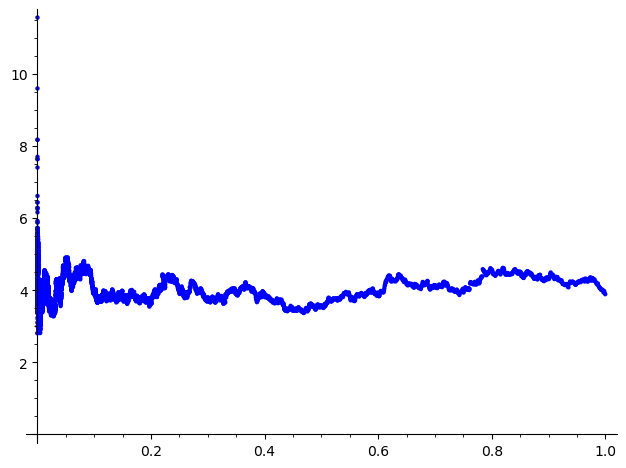

In [10]:
li = list_of_points_for_focus_shifting(E)
print(len(li))
list_plot(li,ymin=0)

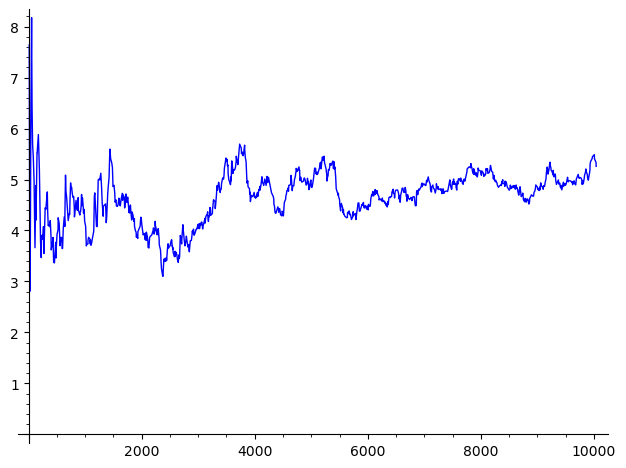

In [23]:

list_plot(li[:1000],plotjoined=True,ymin=0)


In [24]:
li[-1]

[9998099, 3.89033352306145]

In [11]:
import json

lij = [ [int(a[0]), float(a[1])] for a in li]

with open("plotpts_curve_rk2.json", "w") as f:
    json.dump(lij, f)
